# **Caso 9: Predicción de aceptación de ofertas en procesos de selección**

En los procesos de selección, uno de los principales retos no es solo encontrar al candidato adecuado, sino lograr que acepte la oferta final.

Muchas veces, tras semanas de entrevistas y evaluación, el candidato decide rechazar la propuesta, lo que implica pérdida de tiempo, coste y esfuerzo para la empresa.

En este caso de People Analytics, **el objetivo es construir un modelo capaz de predecir si un candidato aceptará o no una oferta**, utilizando únicamente información del proceso de selección y de la propuesta realizada.

Para ello, trabajaremos con un dataset que recoge variables como:

- Duración del proceso

- Número de entrevistas

- Experiencia del candidato durante el proceso

- Condiciones de la oferta (salario, beneficios, modalidad de trabajo)

- Contexto del mercado y del candidato

A partir de estos datos, aplicaremos modelos avanzados de machine learning para identificar qué factores influyen en la decisión final del candidato y estimar la probabilidad de aceptación.

Este tipo de análisis permite a los equipos de recruiting:

a) Anticipar posibles rechazos.

b) Ajustar ofertas antes de lanzarlas.

c) Mejorar la experiencia del candidato.

d) Aumentar la tasa de cierre de posiciones.

En definitiva, *se trata de utilizar datos para tomar mejores decisiones en una de las fases más críticas del proceso de selección: el cierre de la oferta.*

In [1]:
# Cargamos las librerías que vamos a usar

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Procesado y Pre-procesado

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modelos Predictivos y sus métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Stacking
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Cargamos el dataset

url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-case-09-offer-acceptance-prediction-selection-process/main/offer_acceptance_dataset.csv"

employees = pd.read_csv(url)

employees.head()

# Ver primeras filas
employees.head()


,candidate_id,job_family,seniority_level,location_market,process_duration_days,days_to_first_interview,days_between_last_interview_and_offer,num_interviews,num_process_stages,assessment_included,...,final_interview_score,offered_salary_k,salary_increase_pct,bonus_offered,remote_policy,benefits_score,offer_competitiveness_score,candidate_has_other_offers,market_demand_level,offer_accepted
0,CAND_001,IT Support,Mid,Germany,24.0,14,1,5,4,1,...,7,86,20.06,1,Hybrid,8.0,10,0,5,1
1,CAND_002,Cybersecurity,Mid,Spain,39.0,9,2,5,3,1,...,10,30,13.06,1,Remote,10.0,8,1,4,0
2,CAND_003,Cloud,Mid,Spain,46.0,3,8,6,4,1,...,9,100,NaN,0,Hybrid,6.0,4,0,2,0
3,CAND_004,IT Support,Senior,France,38.0,5,5,2,3,0,...,5,87,6.77,0,Onsite,4.0,10,1,3,1
4,CAND_005,Product,Mid,UK,31.0,10,7,4,7,1,...,4,50,NaN,0,Remote,6.0,7,0,1,0


**EDA Preliminar**

In [ ]:
# Vemos tamañano del Dataset

employees.shape

(510, 25)

In [ ]:
# Lo revisamos con un info

employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   candidate_id                           510 non-null    object 
 1   job_family                             510 non-null    object 
 2   seniority_level                        510 non-null    object 
 3   location_market                        510 non-null    object 
 4   process_duration_days                  495 non-null    float64
 5   days_to_first_interview                510 non-null    int64  
 6   days_between_last_interview_and_offer  510 non-null    int64  
 7   num_interviews                         510 non-null    int64  
 8   num_process_stages                     510 non-null    int64  
 9   assessment_included                    510 non-null    int64  
 10  process_changes                        510 non-null    int64  
 11  candid

In [ ]:
# Mostramos solo las columnas que tienen valores nulos

nulls = employees.isnull().sum()
nulls[nulls > 0]

,0
process_duration_days,15
candidate_experience_score,15
salary_increase_pct,15
benefits_score,15


In [ ]:
# Imputamos los valores nulos de las variables numéricas con la mediana
# Usamos la mediana porque es una medida robusta y fácil de justificar

employees["process_duration_days"].fillna(employees["process_duration_days"].median(), inplace=True)
employees["candidate_experience_score"].fillna(employees["candidate_experience_score"].median(), inplace=True)
employees["salary_increase_pct"].fillna(employees["salary_increase_pct"].median(), inplace=True)
employees["benefits_score"].fillna(employees["benefits_score"].median(), inplace=True)

# Comprobamos que ya no quedan valores nulos en el dataset
employees.isnull().sum()

,0
candidate_id,0
job_family,0
seniority_level,0
location_market,0
process_duration_days,0
days_to_first_interview,0
days_between_last_interview_and_offer,0
num_interviews,0
num_process_stages,0
assessment_included,0


In [ ]:
# Detectamos filas duplicadas en el dataset
duplicates = employees.duplicated()

# Número de duplicados
print("Número de filas duplicadas:", duplicates.sum())

Número de filas duplicadas: 8


In [ ]:
# Eliminamos duplicados del dataset
employees = employees.drop_duplicates()

# Verificamos que ya no hay duplicados
print("Duplicados restantes:", employees.duplicated().sum())

# Dimensión final del dataset
print("Shape final:", employees.shape)

Duplicados restantes: 0
Shape final: (502, 25)


**Visualización de Variables:**

In [ ]:
# Identificamos variables numéricas y categóricas

numerical_cols = employees.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = employees.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(numerical_cols)

print("\nVariables categóricas:")
print(categorical_cols)

Variables numéricas:
Index(['process_duration_days', 'days_to_first_interview',
       'days_between_last_interview_and_offer', 'num_interviews',
       'num_process_stages', 'assessment_included', 'process_changes',
       'candidate_experience_score', 'role_fit_score', 'culture_fit_score',
       'manager_rating', 'final_interview_score', 'offered_salary_k',
       'salary_increase_pct', 'bonus_offered', 'benefits_score',
       'offer_competitiveness_score', 'candidate_has_other_offers',
       'market_demand_level', 'offer_accepted'],
      dtype='object')

Variables categóricas:
Index(['candidate_id', 'job_family', 'seniority_level', 'location_market',
       'remote_policy'],
      dtype='object')


In [ ]:
# Descripción estadística de variables numéricas
employees[numerical_cols].describe()

,process_duration_days,days_to_first_interview,days_between_last_interview_and_offer,num_interviews,num_process_stages,assessment_included,process_changes,candidate_experience_score,role_fit_score,culture_fit_score,manager_rating,final_interview_score,offered_salary_k,salary_increase_pct,bonus_offered,benefits_score,offer_competitiveness_score,candidate_has_other_offers,market_demand_level,offer_accepted
count,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000
mean,34.219124,7.352590,5.099602,4.061753,5.005976,0.601594,2.029880,6.615538,7.047809,7.051793,6.944223,6.986056,75.330677,17.079422,0.519920,6.810757,6.884462,0.356574,3.187251,0.892430
std,14.217718,4.042339,2.529278,1.437372,1.448368,0.490058,1.427245,2.182675,1.974312,2.047662,2.042678,1.983415,26.031192,7.393964,0.500101,1.970350,2.051872,0.479465,1.428536,0.310145
min,10.000000,1.000000,1.000000,2.000000,3.000000,0.000000,0.000000,3.000000,4.000000,4.000000,4.000000,4.000000,30.000000,5.020000,0.000000,4.000000,4.000000,0.000000,1.000000,0.000000
25%,22.000000,4.000000,3.000000,3.000000,4.000000,0.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,53.000000,10.345000,0.000000,5.000000,5.000000,0.000000,2.000000,1.000000
50%,34.000000,7.000000,5.000000,4.000000,5.000000,1.000000,2.000000,7.000000,7.000000,7.000000,7.000000,7.000000,76.000000,16.860000,1.000000,7.000000,7.000000,0.000000,3.000000,1.000000
75%,46.000000,11.000000,7.000000,5.000000,6.000000,1.000000,3.000000,8.750000,9.000000,9.000000,9.000000,9.000000,98.000000,23.325000,1.000000,8.000000,9.000000,1.000000,4.000000,1.000000
max,59.000000,14.000000,9.000000,6.000000,7.000000,1.000000,4.000000,10.000000,10.000000,10.000000,10.000000,10.000000,119.000000,29.950000,1.000000,10.000000,10.000000,1.000000,5.000000,1.000000


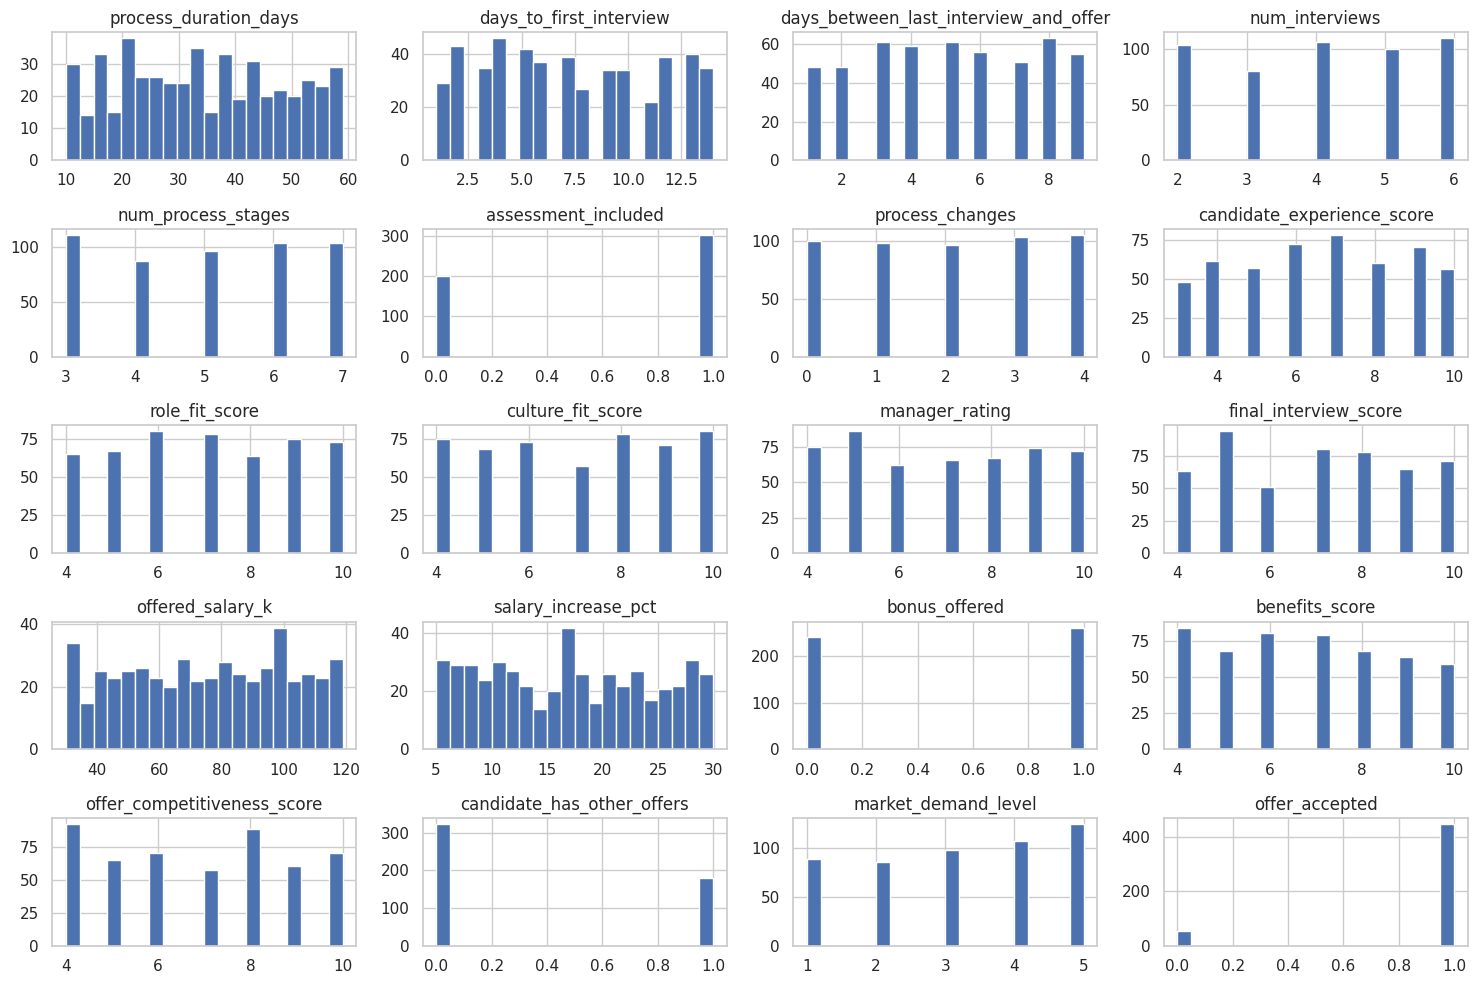

In [ ]:
# Histogramas de variables numéricas
employees[numerical_cols].hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

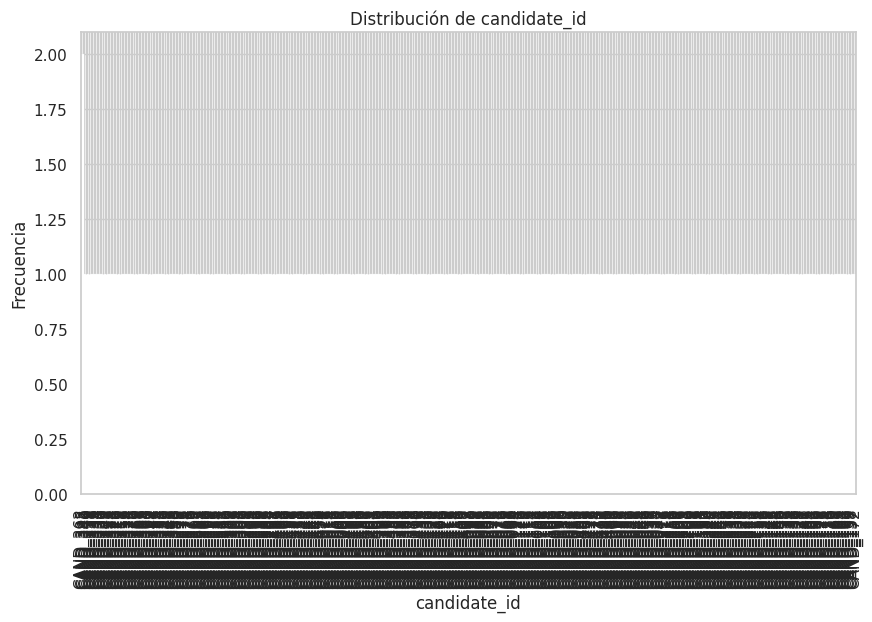

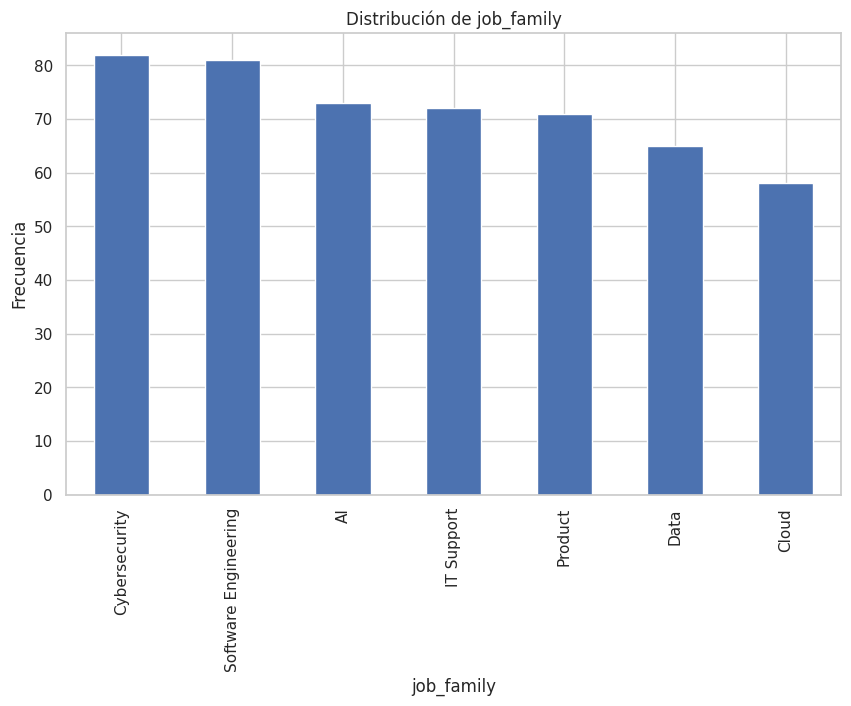

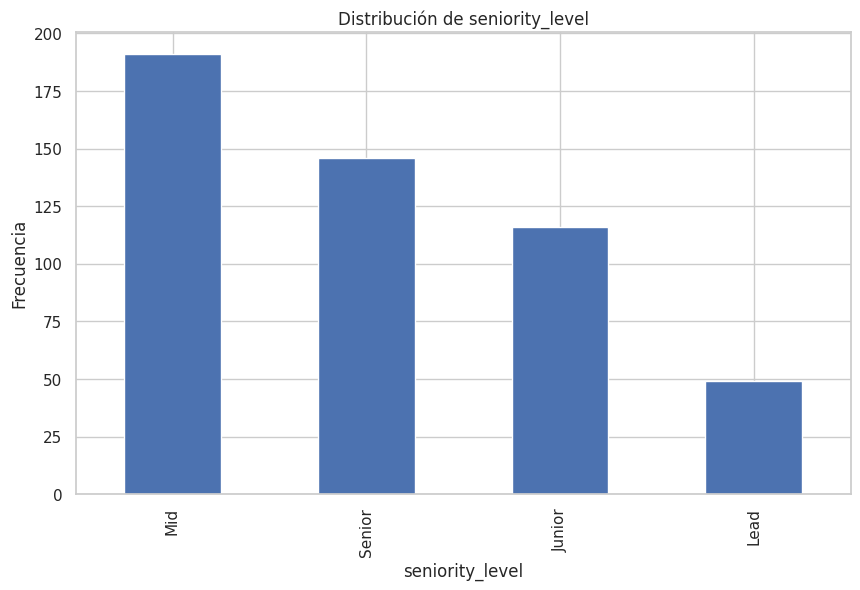

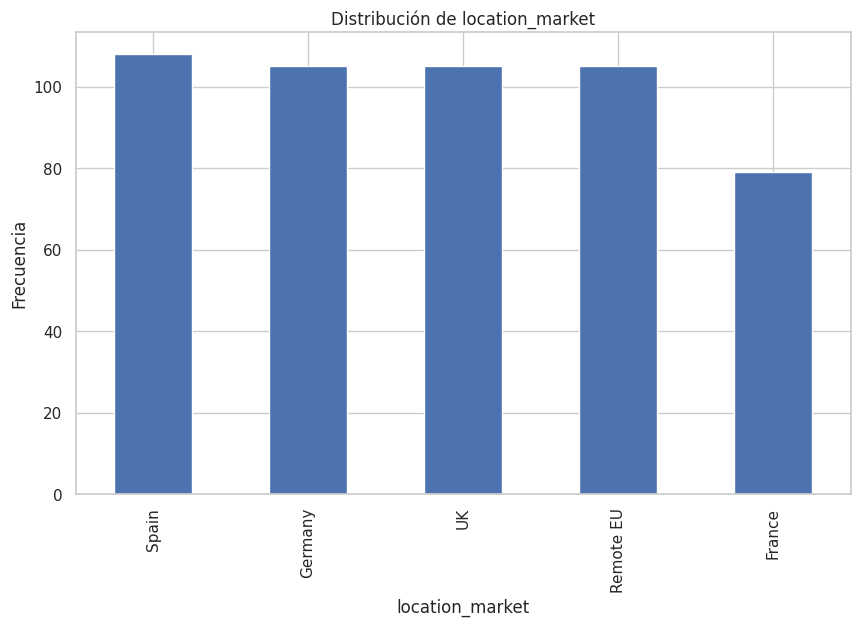

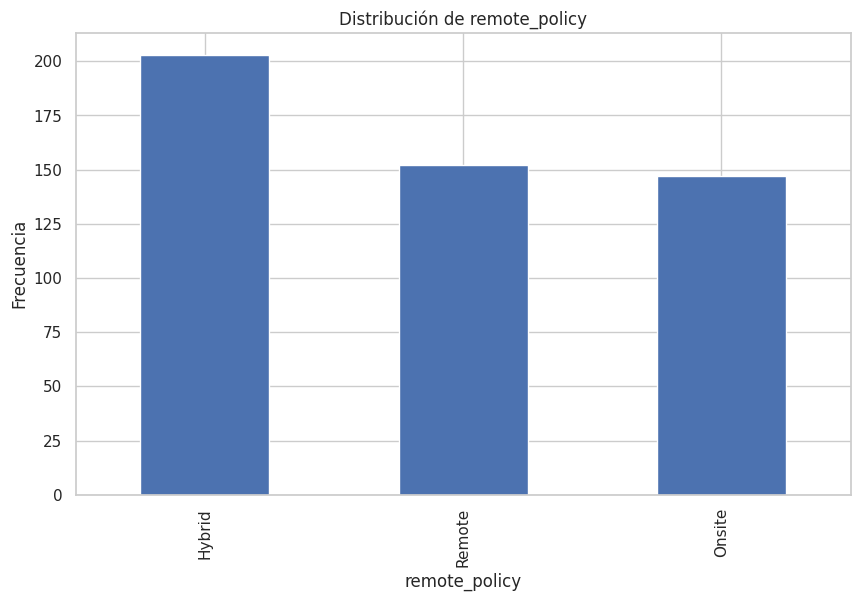

In [ ]:
# Gráficos de barras para variables categóricas
for col in categorical_cols:
    plt.figure()
    employees[col].value_counts().plot(kind='bar')
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

**Correlación con Variables y "target"**

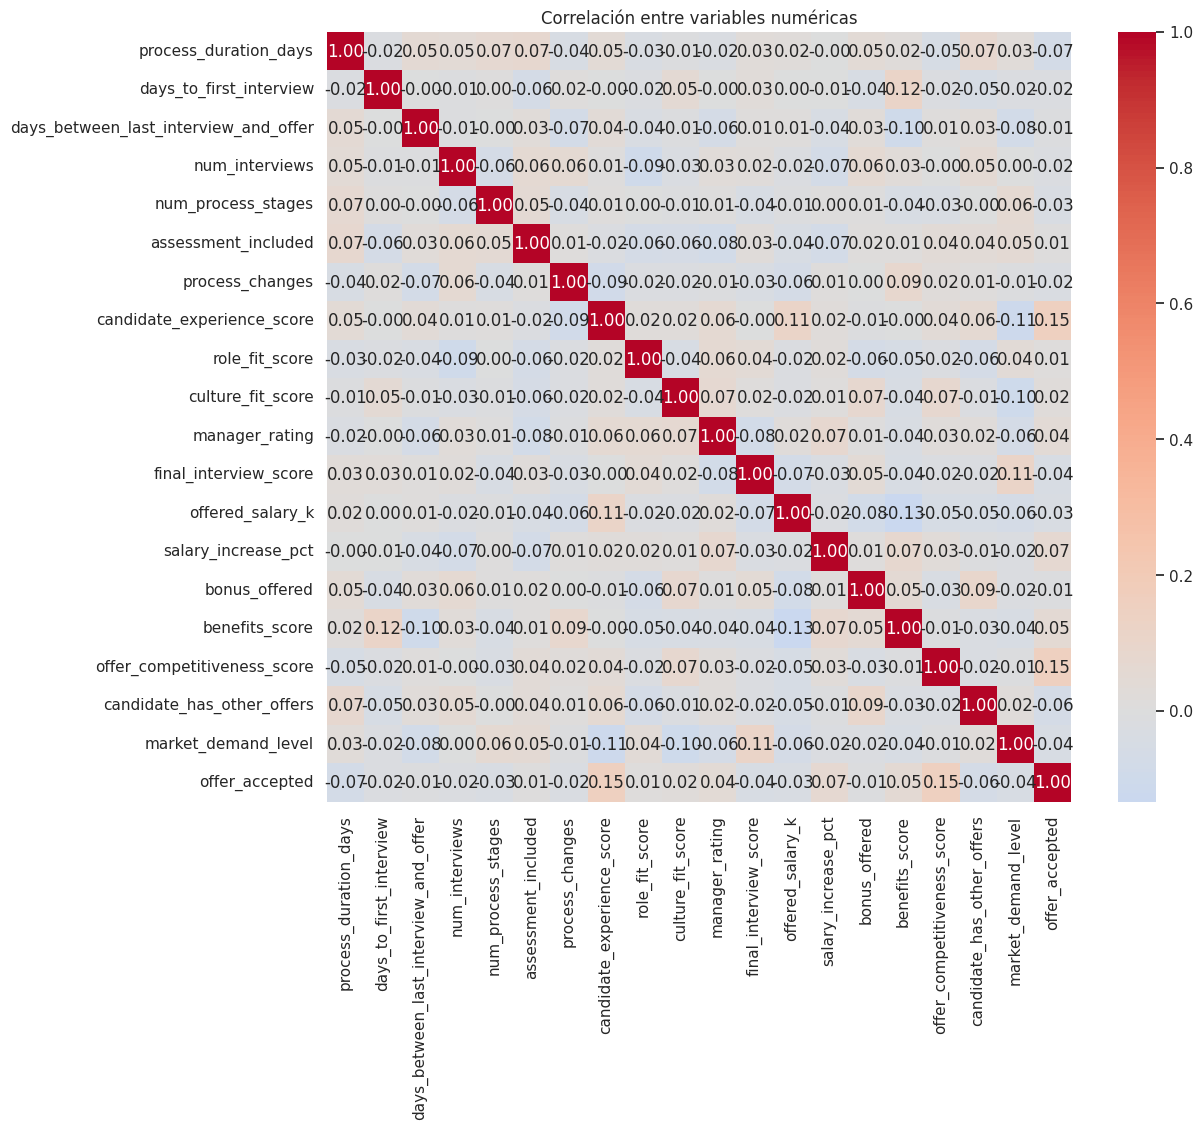

In [ ]:
# Seleccionamos variables numéricas
numerical_cols = employees.select_dtypes(include=["int64", "float64"]).columns

# Matriz de correlación completa
corr_matrix = employees[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

Se observa que:

- No hay relaciones fuertes entre variables, el dataset está bastante equilibrado.

- La experiencia del candidato y lo atractiva que es la oferta son lo que más influye en aceptar.

- Procesos largos o candidatos con otras ofertas hacen más probable el rechazo.

- El salario en sí no parece ser el factor clave.

- La decisión final depende de varios factores a la vez, no de uno solo.

In [ ]:
# Seleccionamos variables categóricas
categorical_cols = employees.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['candidate_id', 'job_family', 'seniority_level', 'location_market',
       'remote_policy'],
      dtype='object')


<Figure size 600x400 with 0 Axes>

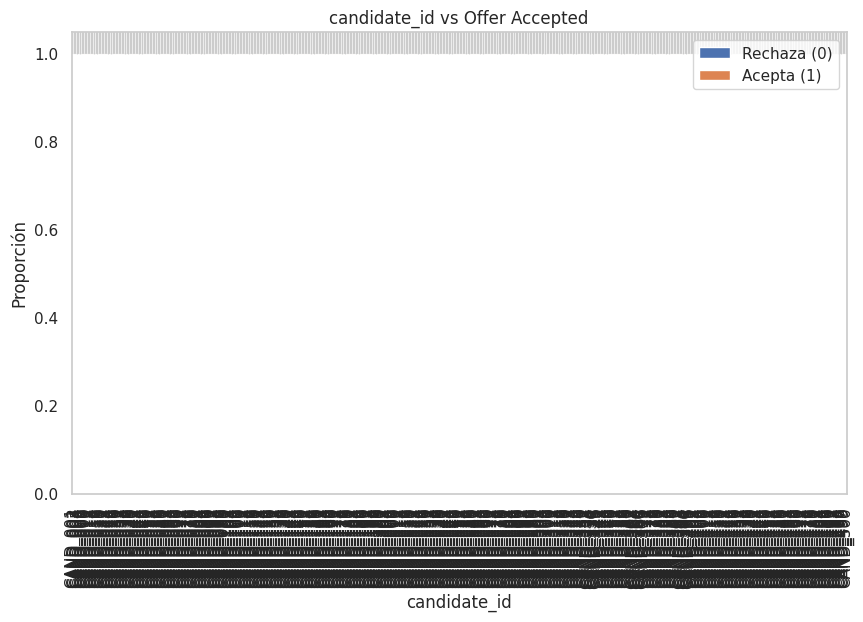

<Figure size 600x400 with 0 Axes>

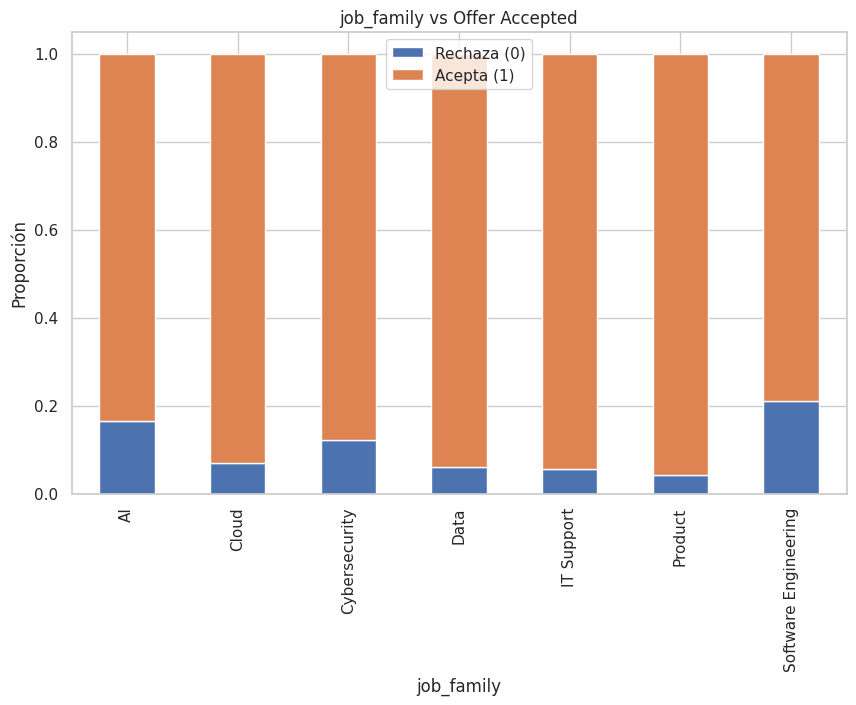

<Figure size 600x400 with 0 Axes>

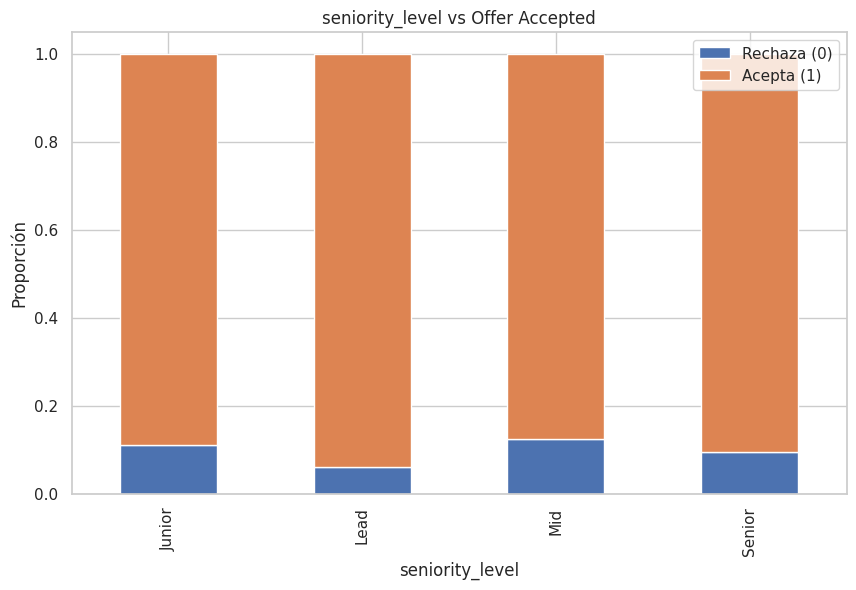

<Figure size 600x400 with 0 Axes>

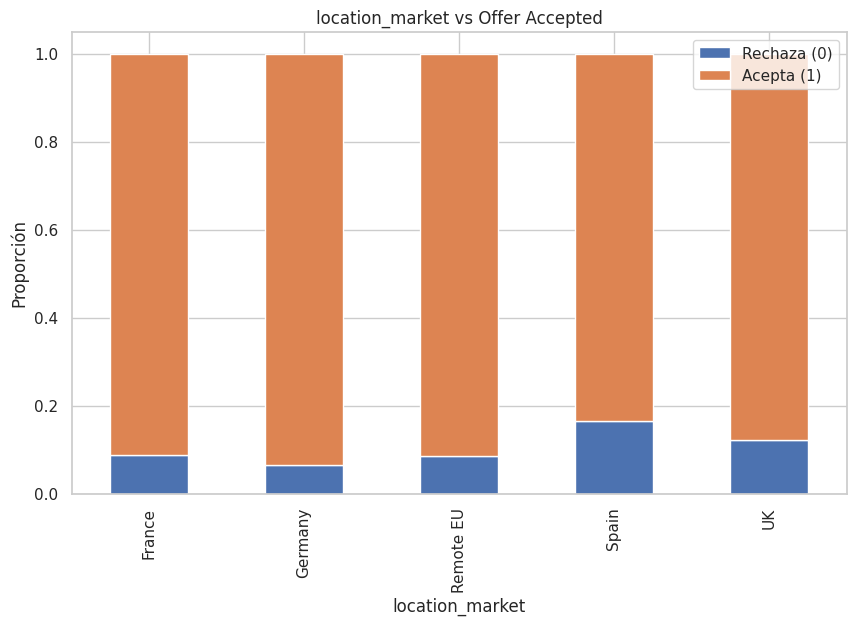

<Figure size 600x400 with 0 Axes>

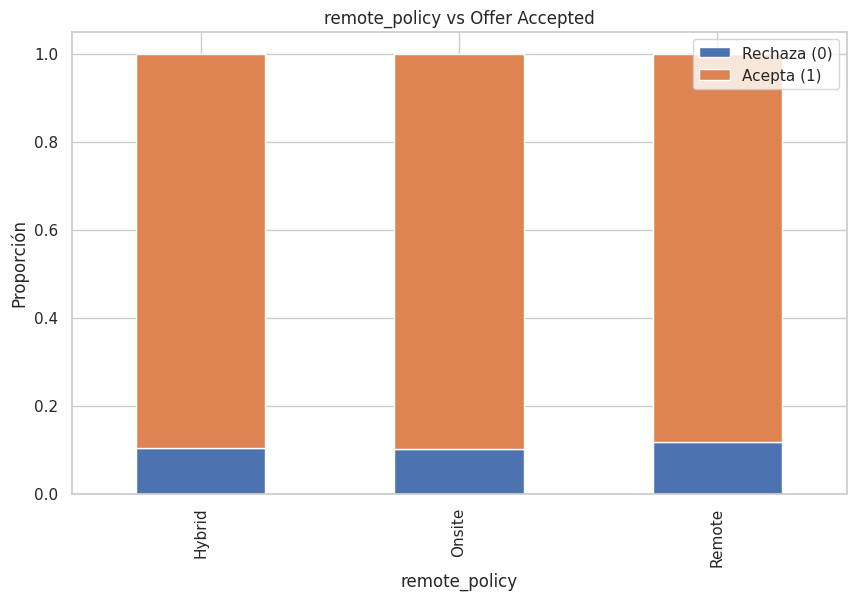

In [ ]:
# Relación entre cada variable categórica y la aceptación de oferta
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    ct = pd.crosstab(employees[col], employees["offer_accepted"], normalize="index")

    ct.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Offer Accepted")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.legend(["Rechaza (0)", "Acepta (1)"])

    plt.show()

Se observa que:

- Las posiciones de Ingeniería, IA y Ciberseguridad tienen a rechazar oferta más a menudo.

- Afecta más a perfiles junior y medios.

- No influye la modalidad del trabajo (Presencial, Híbrido o Remoto).

- Es un problema mayor en España.

# **Modelado predictivo: aceptación de ofertas**

Tras limpiar y analizar los datos, construiremos un modelo que prediga si un candidato aceptará una oferta.

Usaremos **XGBoost y LightGBM**, dos modelos muy eficaces para este tipo de datos, y **los combinaremos con stacking para mejorar el resultado.**

**El objetivo es estimar la probabilidad de aceptación** (offer_accepted) y *entender qué factores influyen más en la decisión.*

Esto **permitirá anticipar rechazos y ajustar mejor las ofertas** en procesos de selección.

In [ ]:
# Revisamos el balance de la variable objetivo
employees["offer_accepted"].value_counts()

,count
offer_accepted,
1,448
0,54


In [ ]:
# Porcentaje de cada clase
employees["offer_accepted"].value_counts(normalize=True) * 100

,proportion
offer_accepted,
1,89.243028
0,10.756972


El target está desbalanceado, por lo que debejo ajustarlo:

In [ ]:
# Calculamos peso para clases desbalanceadas
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [ ]:
# Definimos variable objetivo
y = employees["offer_accepted"]

# Eliminamos target y ID de las variables predictoras
X = employees.drop(columns=["offer_accepted", "candidate_id"])

In [ ]:
# Dividimos en train y test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Convertimos variables categóricas en variables dummy (one-hot encoding)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Aseguramos que train y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [ ]:
# Entrenamos el primer modelo base con XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Entrenamos el segundo modelo con LightGBM
lgb_model = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

lgb_model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

In [ ]:
# Precisión en train y test de ambos modelos

# XGBoost

# Train
y_train_pred_xgb = xgb_model.predict(X_train)
acc_train_xgb = accuracy_score(y_train, y_train_pred_xgb)

# Test
y_test_pred_xgb = xgb_model.predict(X_test)
acc_test_xgb = accuracy_score(y_test, y_test_pred_xgb)

# LightGBM

# Train
y_train_pred_lgb = lgb_model.predict(X_train)
acc_train_lgb = accuracy_score(y_train, y_train_pred_lgb)

# Test
y_test_pred_lgb = lgb_model.predict(X_test)
acc_test_lgb = accuracy_score(y_test, y_test_pred_lgb)

# Resultados
print("XGBoost -> Train:", round(acc_train_xgb, 3), "| Test:", round(acc_test_xgb, 3))
print("LightGBM -> Train:", round(acc_train_lgb, 3), "| Test:", round(acc_test_lgb, 3))

XGBoost -> Train: 0.993 | Test: 0.871
LightGBM -> Train: 1.0 | Test: 0.871


Se observa que ambos modelos presentan un rendimiento muy alto en el conjunto de entrenamiento, pero menor en el conjunto de test, lo que indica cierto grado de sobreajuste.

Además, el accuracy es muy similar en ambos modelos, por lo que ninguno destaca claramente sobre el otro en esta métrica.

Sin embargo, dado que el dataset está desbalanceado (la mayoría de candidatos aceptan la oferta), el accuracy no es suficiente para evaluar correctamente el modelo, por lo que será necesario analizar métricas adicionales.

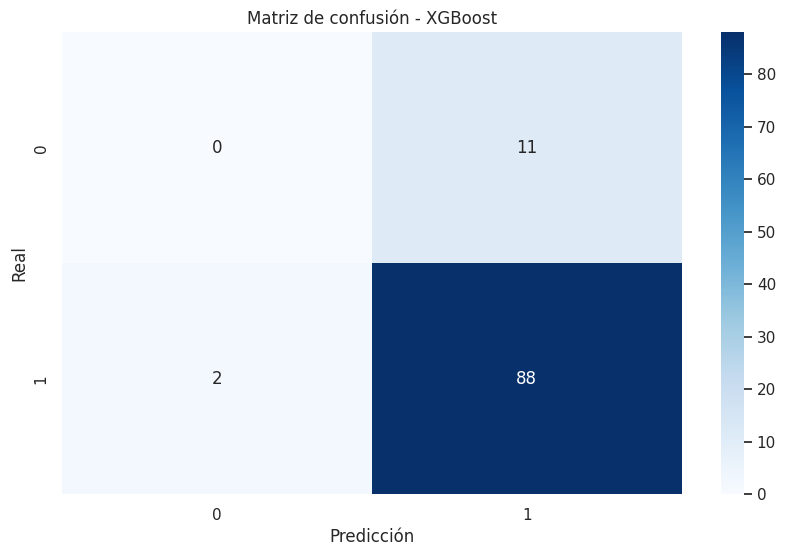

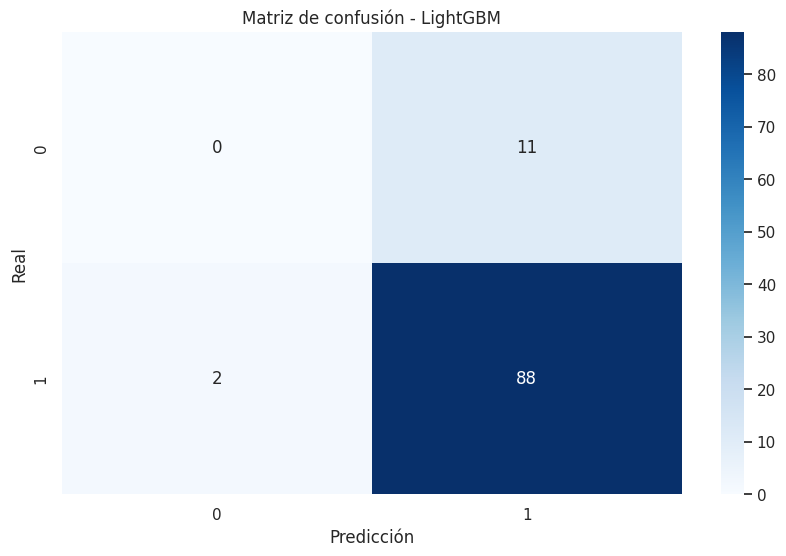

In [ ]:
# Analizamos la matriz de confusión para entender mejor
# cómo están clasificando los modelos (aciertos y errores)

# Matriz de Confusión

#XGBoost

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# LightGBM

cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)

plt.figure()
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - LightGBM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

**En este caso la medida más importante es el Recall en rechazos**, y **no predecimos ninguno.**

Conclusión: **El modelo no detecta rechazos porque el dataset no contiene suficiente señal explicativa para esa clase.**

Para conseguir, **necesita más información sobre "rechazos de oferta"**

***Solución: nutrir el dataset de más información***

In [ ]:
# Revisamos la distribución actual del target
employees["offer_accepted"].value_counts(normalize=True) * 100

,proportion
offer_accepted,
1,89.243028
0,10.756972


In [ ]:
# Copia del dataset
employees_v2 = employees.copy()

# Score simple de riesgo
employees_v2["risk_score"] = (
    (employees_v2["candidate_experience_score"] <= 5).astype(int) * 3 +
    (employees_v2["process_duration_days"] >= 40).astype(int) * 3 +
    (employees_v2["salary_increase_pct"] <= 10).astype(int) * 3 +
    (employees_v2["offer_competitiveness_score"] <= 5).astype(int) * 3 +
    (employees_v2["candidate_has_other_offers"] == 1).astype(int) * 2 +
    (employees_v2["remote_policy"] == "Onsite").astype(int) * 2 +
    (employees_v2["benefits_score"] <= 6).astype(int) * 2 +
    (employees_v2["num_interviews"] >= 5).astype(int) * 1 +
    (employees_v2["process_changes"] >= 2).astype(int) * 1
)

# Ordenamos por riesgo
employees_v2 = employees_v2.sort_values(
    by=["risk_score", "candidate_id"],
    ascending=[False, True]
)

# Reasignamos target
cutoff = int(len(employees_v2) * 0.35)
employees_v2["offer_accepted"] = 1
employees_v2.iloc[:cutoff, employees_v2.columns.get_loc("offer_accepted")] = 0

# Limpieza
employees_v2 = employees_v2.drop(columns=["risk_score"])

# Sustituimos dataset
employees = employees_v2.copy()

In [ ]:
# Revisamos cómo queda la variable objetivo tras el ajuste
employees_v2["offer_accepted"].value_counts(normalize=True) * 100

,proportion
offer_accepted,
1,65.139442
0,34.860558


**Ya tenemos un dataset más balanceado.**

Para **mejorar el modelo**, hacemos *un Stacking de XGBoost y LightGBM*.



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Definimos modelo de stacking
stack_model = StackingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("lgb", lgb_model)
    ],
    final_estimator=LogisticRegression(class_weight="balanced"),
    cv=5,
    n_jobs=-1
)

# Entrenamos
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interac...
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(class_weight='balanced',
                                               random_state=42, verbose=-1))],
                   final_estimator=LogisticRegression(class_weight='balanced'),
                   n_jobs=-1)

In [ ]:
# Predicciones stacking
y_pred_stack = stack_model.predict(X_test)
y_proba_stack = stack_model.predict_proba(X_test)[:, 1]

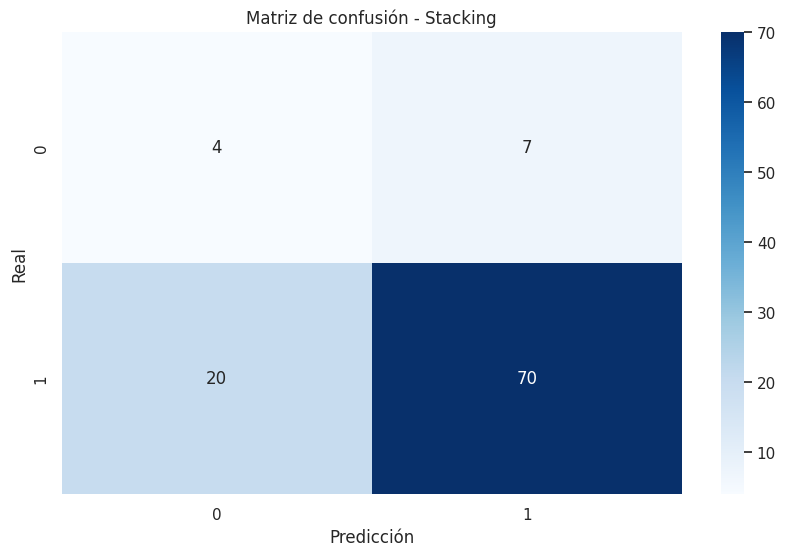

In [ ]:
# Matriz de confusión del modelo de stacking
cm_stack = confusion_matrix(y_test, y_pred_stack)

plt.figure()
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Stacking")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Tras ajustar el modelo de stacking, **incorporando balanceo de clases en el estimador final**, se **mejora la capacidad para detectartexto en negritacandidatos que rechazan la oferta.**

Aunque existe un trade-off en la precisión sobre las aceptaciones, **el modelo logra identificar aproximadamente un tercio de los rechazos**, lo que permite anticipar riesgos y tomar decisiones más informadas en el proceso de selección.

# **Conclusiones**

* El modelo inicial parecía bueno, pero no detectaba rechazos, por lo que no era útil para negocio.
* El problema no estaba en el modelo, sino en los datos (poca señal y desbalanceo).
* Al mejorar el dataset y ajustar el modelo, se empezó a detectar correctamente a candidatos con riesgo de rechazo.
* El modelo final permite anticipar parte de los rechazos y entender qué factores influyen en la decisión.
* En People Analytics, la calidad de los datos es más importante que el algoritmo utilizado.


# **Impacto en negocio**

El modelo permite identificar candidatos con riesgo de rechazo antes de que la oferta sea finalmente rechazada.

Esto permite a los equipos de recruiting actuar de forma proactiva (mejorar la oferta, acelerar el proceso o ajustar condiciones), aumentando la probabilidad de cierre.

A continuación, **se realiza una simulación sencilla para estimar el impacto económico de reducir los rechazos, gracias al uso del modelo.**


In [ ]:
# Supuesto: volumen anual de contrataciones
annual_hires = 200

# Ratio de rechazo del dataset
rejection_rate = 0.35

# Rechazos anuales estimados
annual_rejections = annual_hires * rejection_rate

# % de rechazos que el modelo detecta
detection_rate = detected_rejections / real_rejections

# Casos detectados al año
detected_annual = annual_rejections * detection_rate

# Recuperación
recoverable_annual = detected_annual * recovery_rate

# Impacto económico
annual_savings = recoverable_annual * cost_per_rejection

print(f"Rechazos anuales estimados: {annual_rejections:.0f}")
print(f"Rechazos detectados por el modelo: {detected_annual:.0f}")
print(f"Casos recuperables: {recoverable_annual:.0f}")
print(f"Ahorro anual estimado: €{annual_savings:,.0f}")

Rechazos anuales estimados: 70
Rechazos detectados por el modelo: 25
Casos recuperables: 8
Ahorro anual estimado: €114,545


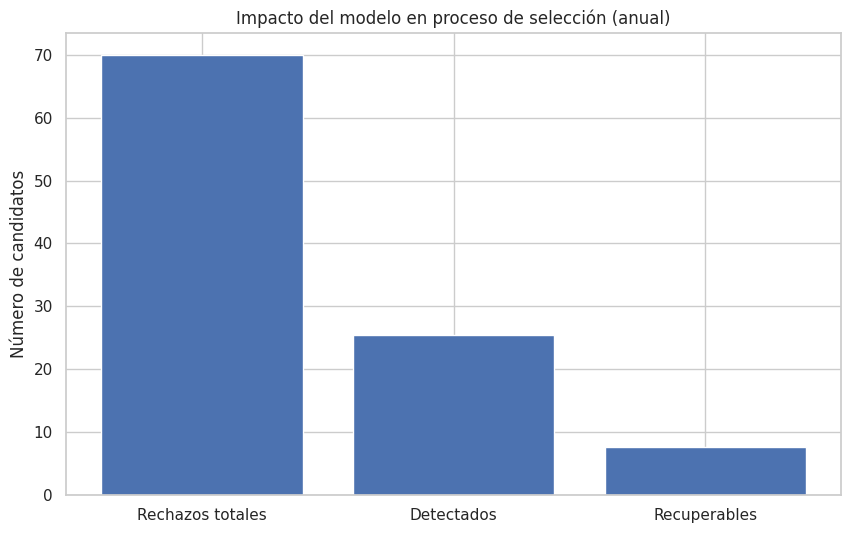

In [ ]:
# Datos para visualización
labels = ["Rechazos totales", "Detectados", "Recuperables"]
values = [annual_rejections, detected_annual, recoverable_annual]

plt.figure()
plt.bar(labels, values)

plt.title("Impacto del modelo en proceso de selección (anual)")
plt.ylabel("Número de candidatos")

plt.show()

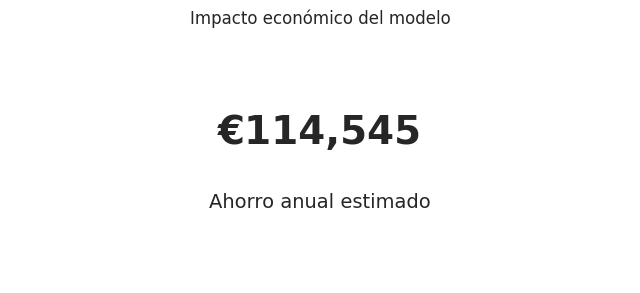

In [ ]:
# KPI visual de impacto económico

plt.figure(figsize=(8, 3))
plt.axis("off")

plt.text(
    0.5, 0.65,
    f"€{annual_savings:,.0f}",
    ha="center", va="center",
    fontsize=28, fontweight="bold"
)

plt.text(
    0.5, 0.35,
    "Ahorro anual estimado",
    ha="center", va="center",
    fontsize=14
)

plt.title("Impacto económico del modelo", pad=20)
plt.show()

Aunque la simulación sobre el conjunto de test muestra un impacto limitado, **al escalar el modelo a volúmenes reales de contratación el potencial de ahorro se vuelve significativo**, permitiendo **recuperar candidatos valiosos y optimizar los costes asociados al proceso de selección.**
